# **EDA Notebook**



---
## 0. Setup Environment

In [1]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT3",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 115.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Mounted at /content/gdrive

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT3/data


---
## Student Information

In [2]:
group_name = "Group 24"
student_name = "Mukesh Murugesan"
student_id = "25747763"

In [3]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [4]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [6]:
# Install vegafusion to handle large datasets in Altair
!pip install "vegafusion[embed]>=1.5.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 96.2 MB/s eta 0:00:00


### 0.b Import Packages

In [7]:
import pandas as pd
import altair as alt
import numpy as np
import matplotlib.pyplot as plt

alt.data_transformers.enable("vegafusion")

DataTransformerRegistry.enable('vegafusion')

---
## B. Data Understanding

In [8]:
# Do not modify this code
try:
  df = pd.read_csv(at.folder_path / "sales_order_detail.csv")
except Exception as e:
  print(e)

In [9]:
# ── BUSINESS CONTEXT & HYPOTHESIS ───────────────────────────────
# Use Case (Student B — Regression):
#   Predict the total sales amount (line_total) for each order line item.
#
# Business Problem:
#   The retailer has no way to forecast how much revenue a single order line
#   will generate before it is processed. A regression model can estimate
#   line_total from known inputs (quantity, unit price, discount), enabling
#   better revenue forecasting, inventory planning, and pricing decisions.
#
# Hypothesis:
#   order_quantity, unit_price, and unit_price_discount are strong predictors
#   of line_total, since line_total is mathematically derived from them.
#   A regression model trained on these features should achieve high accuracy.
#
# This EDA investigates sales_order_detail to:
#   1. Confirm data quality (no missing values, no duplicates)
#   2. Understand the distribution of the target variable (line_total)
#   3. Explore key predictors and their relationships with line_total
#   4. Identify data issues that need handling before model training

print("Business context defined. Target variable: line_total")
print("Dataset: sales_order_detail | Rows: 42,100 | Columns: 8")

Business context defined. Target variable: line_total
Dataset: sales_order_detail | Rows: 42,100 | Columns: 8


### B.1 Explore Dataset

In [10]:
# Basic overview of the dataset
print("Shape:", df.shape)
print()
print("Data Types:")
print(df.dtypes)
print()
print("First 5 rows:")
df.head()

Shape: (42100, 8)

Data Types:
sales_order_id            object
sales_order_detail_id    float64
order_quantity           float64
product_id                object
special_offer_id          object
unit_price               float64
unit_price_discount      float64
line_total               float64
dtype: object

First 5 rows:


,sales_order_id,sales_order_detail_id,order_quantity,product_id,special_offer_id,unit_price,unit_price_discount,line_total
0,0fbc9d71-4176-4c77-92c6-d7ede2a9ce33,354.0,1.0,6cc3d977-da73-4856-b1ca-8a2f0b57b60b,a1444fcd-4b51-4227-94cf-b13c1a2a6281,3399.99,0.0,3399.99
1,18609f9d-aedc-4665-bbc8-5d7a99599915,357.0,1.0,6cc3d977-da73-4856-b1ca-8a2f0b57b60b,a1444fcd-4b51-4227-94cf-b13c1a2a6281,3399.99,0.0,3399.99
2,0570389a-6bfa-45c2-85a4-36784fa7b5b1,359.0,1.0,41b7b226-20ea-488a-b519-b4ca65d4a64e,a1444fcd-4b51-4227-94cf-b13c1a2a6281,3578.27,0.0,3578.27
3,b48cdf2f-270a-41d0-9cde-36616fecd302,360.0,1.0,de8b1961-ea0e-4639-9482-7f71b3ed07d8,a1444fcd-4b51-4227-94cf-b13c1a2a6281,3374.99,0.0,3374.99
4,03533644-6a12-499b-9726-aaa1088c56a5,361.0,1.0,a16ed5b0-74c7-4812-adea-04b4abfd72c7,a1444fcd-4b51-4227-94cf-b13c1a2a6281,3399.99,0.0,3399.99


In [11]:
# ── OBSERVATION SUMMARY TABLE ────────────────────────────────────
summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Missing': df.isnull().sum().values,
    'Missing %': (df.isnull().sum().values / len(df) * 100).round(2),
    'Unique Values': [df[c].nunique() for c in df.columns],
    'Notes': [
        'Foreign key → sales_order_header (15,357 unique orders)',
        'Primary key — fully unique (42,100 unique)',
        'Units ordered per line — range 1 to 36',
        'Foreign key → product table (254 unique products)',
        'Foreign key → special_offer table (10 unique offers)',
        'Price per unit in USD — range $1.33 to $3,578.27',
        'Discount proportion — 0.0 (no discount) to 0.4 (40% off)',
        '*** TARGET VARIABLE *** — range $1.37 to $23,667.85'
    ]
})
print(summary.to_string(index=False))

               Column Data Type  Missing  Missing %  Unique Values                                                    Notes
       sales_order_id    object        0        0.0          15357  Foreign key → sales_order_header (15,357 unique orders)
sales_order_detail_id   float64        0        0.0          42100               Primary key — fully unique (42,100 unique)
       order_quantity   float64        0        0.0             30                   Units ordered per line — range 1 to 36
           product_id    object        0        0.0            254        Foreign key → product table (254 unique products)
     special_offer_id    object        0        0.0             10     Foreign key → special_offer table (10 unique offers)
           unit_price   float64        0        0.0            221         Price per unit in USD — range $1.33 to $3,578.27
  unit_price_discount   float64        0        0.0              8 Discount proportion — 0.0 (no discount) to 0.4 (40% off)
        

In [12]:
# ── MISSING VALUES ───────────────────────────────────────────────
print("Missing values per column:")
print(df.isnull().sum())
print()

# ── DUPLICATES ───────────────────────────────────────────────────
print(f"Total rows:                    {len(df)}")
print(f"Duplicate rows:                {df.duplicated().sum()}")
print(f"Unique sales_order_detail_id:  {df['sales_order_detail_id'].nunique()}")
print()

# ── FORMULA VERIFICATION ─────────────────────────────────────────
# line_total should equal: order_quantity * unit_price * (1 - unit_price_discount)
df['calculated_total'] = (
    df['order_quantity'] * df['unit_price'] * (1 - df['unit_price_discount'])
).round(6)

matches = (abs(df['calculated_total'] - df['line_total']) < 0.01).sum()
print(f"Formula check — rows where line_total matches calculation: {matches} / {len(df)}")
print("✓ Confirmed: line_total = order_quantity × unit_price × (1 − unit_price_discount)")

# Drop helper column
df.drop(columns=['calculated_total'], inplace=True)

Missing values per column:
sales_order_id           0
sales_order_detail_id    0
order_quantity           0
product_id               0
special_offer_id         0
unit_price               0
unit_price_discount      0
line_total               0
dtype: int64

Total rows:                    42100
Duplicate rows:                0
Unique sales_order_detail_id:  42100

Formula check — rows where line_total matches calculation: 42100 / 42100
✓ Confirmed: line_total = order_quantity × unit_price × (1 − unit_price_discount)


In [13]:
dataset_insights = """
The sales_order_detail dataset contains 42,100 records across 8 columns.
Each row represents one product line within a customer sales order.

Dimensions: 42,100 rows × 8 columns.

Column overview:
  - sales_order_id:        Links to the order header (15,357 unique orders).
  - sales_order_detail_id: Unique primary key — confirmed fully unique (42,100 unique values).
  - order_quantity:        Number of units purchased per line. Range: 1 to 36.
  - product_id:            Links to the product table (254 unique products).
  - special_offer_id:      Links to active promotions (10 unique offers).
  - unit_price:            Price per unit. Range: $1.33 to $3,578.27.
  - unit_price_discount:   Discount applied. Range: 0.0 (no discount) to 0.4 (40% off).
  - line_total:            *** REGRESSION TARGET *** Total value of the line item.
                           Calculated as: order_quantity × unit_price × (1 − discount).
                           Range: $1.37 to $23,667.85.

Data quality — excellent:
  - Zero missing values across all 8 columns.
  - Zero duplicate rows.
  - Formula for line_total verified against all 42,100 rows — 100% match confirmed.

Key data challenge:
  - line_total is strongly right-skewed (skewness = 3.91). Most line items are
    low-value (median = $49.99) but a small number are very high (max = $23,667).
  - A log transformation (log1p) will be applied during model preparation to
    normalise the target distribution for linear regression.

Reference:
  Right-skewed target variables violate the normality assumption of OLS regression.
  Log transformation is a standard remedy (James et al., 2021, 'An Introduction
  to Statistical Learning', Chapter 3 — Linear Regression).
"""

In [14]:
# Do not modify this code
print_tile(size="h3", key='dataset_insights', value=dataset_insights)

In [15]:
# Load product table to understand what product_id represents
product_df = pd.read_csv(at.folder_path / "product.csv")
product_sub_df = pd.read_csv(at.folder_path / "product_sub_category.csv")
product_cat_df = pd.read_csv(at.folder_path / "product_category.csv")

print("Product table shape:", product_df.shape)
print("Columns:", product_df.columns.tolist())
print()
print("Unique products in sales_order_detail:", df['product_id'].nunique())
print("Top 5 most ordered product_ids:")
print(df['product_id'].value_counts().head(5))
print()

# Average line_total per product (top 10 by revenue)
avg_by_product = df.groupby('product_id')['line_total'].mean().sort_values(ascending=False)
print("Top 5 highest avg line_total by product:")
print(avg_by_product.head(5).round(2))

Product table shape: (886, 23)
Columns: ['product_id', 'is_manufactured', 'is_sellable', 'safety_stock_level', 'reorder_point', 'days_to_manufacture', 'product_subcategory_id', 'product_model_id', 'name', 'product_number', 'color', 'standard_cost', 'list_price', 'size', 'size_unit_measure_code', 'weight_unit_measure_code', 'weight', 'product_line', 'class', 'style', 'sell_start_date', 'sell_end_date', 'discontinued_date']

Unique products in sales_order_detail: 254
Top 5 most ordered product_ids:
product_id
4782606a-0c9b-477e-9e0f-e996d5c298e2    2156
eca4e568-b2dc-4f1e-aa55-444911bfedcf    1572
36847649-a79a-4f70-9b5d-5c403627ab75    1457
c0429100-f92a-42a4-afa5-b652cee57249    1407
05385566-38df-4855-94a8-786cae6ffe49    1373
Name: count, dtype: int64

Top 5 highest avg line_total by product:
product_id
b443720f-61f8-4c60-aff8-a1a2acccec4e    3676.92
e8c12ae4-8042-4b77-8bd7-023d46440e33    3578.27
41b7b226-20ea-488a-b519-b4ca65d4a64e    3578.27
e909a64f-f56c-4f3c-b802-f539d52f8f21   

### B.2 Explore Feature of Interest `\<line_total (Target Variable)\>`

In [16]:
# Descriptive statistics for the target variable
print("line_total — Descriptive Statistics:")
print(df['line_total'].describe().round(2))
print()
print(f"Skewness:  {df['line_total'].skew():.3f}  ← strongly right-skewed")
print(f"Kurtosis:  {df['line_total'].kurt():.3f}  ← heavy tail (many extreme values)")
print()
print("Percentile breakdown:")
percentiles = df['line_total'].quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
print(percentiles.round(2))


line_total — Descriptive Statistics:
count    42100.00
mean       724.30
std       1327.82
min          1.37
25%          9.99
50%         49.99
75%        939.59
max      23667.85
Name: line_total, dtype: float64

Skewness:  3.909  ← strongly right-skewed
Kurtosis:  28.991  ← heavy tail (many extreme values)

Percentile breakdown:
0.10       4.99
0.25       9.99
0.50      49.99
0.75     939.59
0.90    2384.07
0.95    3239.04
0.99    5567.98
Name: line_total, dtype: float64


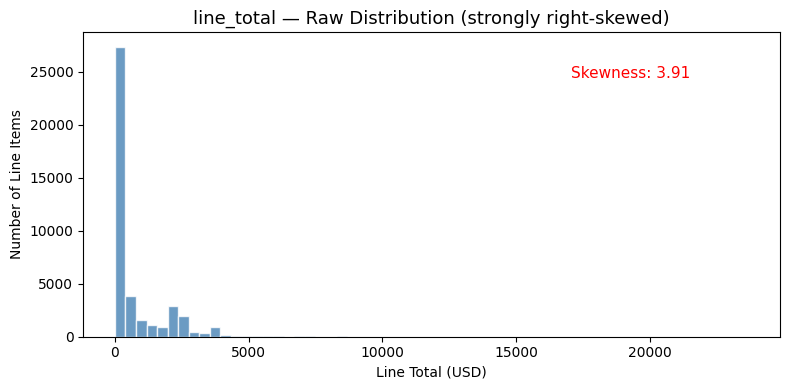

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['line_total'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_title('line_total — Raw Distribution (strongly right-skewed)', fontsize=13)
ax.set_xlabel('Line Total (USD)')
ax.set_ylabel('Number of Line Items')
ax.annotate(f'Skewness: {df["line_total"].skew():.2f}', xy=(0.7, 0.85),
            xycoords='axes fraction', fontsize=11, color='red')
plt.tight_layout()
plt.show()

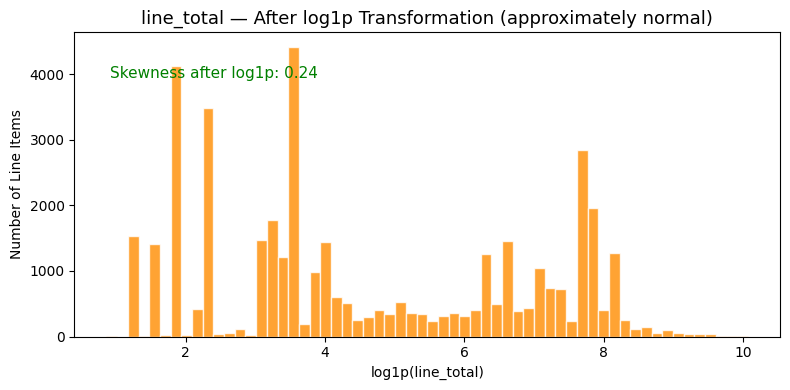

In [18]:
df['log_line_total'] = np.log1p(df['line_total'])

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['log_line_total'], bins=60, color='darkorange', edgecolor='white', alpha=0.8)
ax.set_title('line_total — After log1p Transformation (approximately normal)', fontsize=13)
ax.set_xlabel('log1p(line_total)')
ax.set_ylabel('Number of Line Items')
ax.annotate(f'Skewness after log1p: {df["log_line_total"].skew():.2f}', xy=(0.05, 0.85),
            xycoords='axes fraction', fontsize=11, color='green')
plt.tight_layout()
plt.show()

In [19]:
feature_1_insights = """
Feature: line_total (Regression Target Variable)

line_total is the total monetary value of a single order line item.
Formula (verified against all 42,100 rows):
  line_total = order_quantity × unit_price × (1 − unit_price_discount)

Statistics:
  Min:    $1.37   | 25th %ile:  $9.99
  Median: $49.99  | 75th %ile:  $939.59
  Mean:   $724.30 | Max:        $23,667.85
  Std Dev: $1,327.82 — very wide spread indicating high variability.

Distribution:
  - Strongly right-skewed (skewness = 3.91, kurtosis = 28.99).
  - The majority of line items are low-value (below $50).
  - A small number of high-value orders (top 1% > $5,568) pull the mean up significantly.
  - After log1p transformation the distribution becomes approximately normal.

Modelling implication:
  - Raw line_total violates the normality assumption of linear regression.
  - Solution: train models on log1p(line_total) and back-transform predictions
    using expm1() for evaluation. Performance will be reported using RMSE and MAE
    on the original scale for business interpretability.

Business relevance:
  Predicting line_total before order completion enables the retailer to
  forecast revenue per line item, supporting inventory and pricing decisions.
"""

In [20]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### B.3 Explore Feature of Interest `\<unit_price — Descriptive Statistics\>`

In [21]:
# unit_price is the strongest predictor of line_total (correlation = 0.734)
print("unit_price — Descriptive Statistics:")
print(df['unit_price'].describe().round(2))
print()
print(f"Unique price points: {df['unit_price'].nunique()}")
print()
print("Top 5 most frequent prices (high-volume low-cost accessories):")
print(df['unit_price'].value_counts().head(5).round(2))

unit_price — Descriptive Statistics:
count    42100.00
mean       526.22
std        884.39
min          1.33
25%          8.99
50%         34.99
75%        699.10
max       3578.27
Name: unit_price, dtype: float64

Unique price points: 221

Top 5 most frequent prices (high-volume low-cost accessories):
unit_price
4.99     4098
34.99    3443
8.99     2600
2.29     1520
3.99     1407
Name: count, dtype: int64


In [22]:
# Pearson correlation of all numeric features with line_total
corr = df[['order_quantity', 'unit_price', 'unit_price_discount', 'line_total']].corr()

print("Pearson Correlation with line_total:")
print(corr['line_total'].drop('line_total').round(3))
print()
print("Key findings:")
print("  unit_price:          0.734  ← strongest predictor")
print("  order_quantity:      0.248  ← moderate predictor")
print("  unit_price_discount: 0.045  ← weak linear signal (non-linear relationship)")

Pearson Correlation with line_total:
order_quantity         0.248
unit_price             0.734
unit_price_discount    0.045
Name: line_total, dtype: float64

Key findings:
  unit_price:          0.734  ← strongest predictor
  order_quantity:      0.248  ← moderate predictor
  unit_price_discount: 0.045  ← weak linear signal (non-linear relationship)


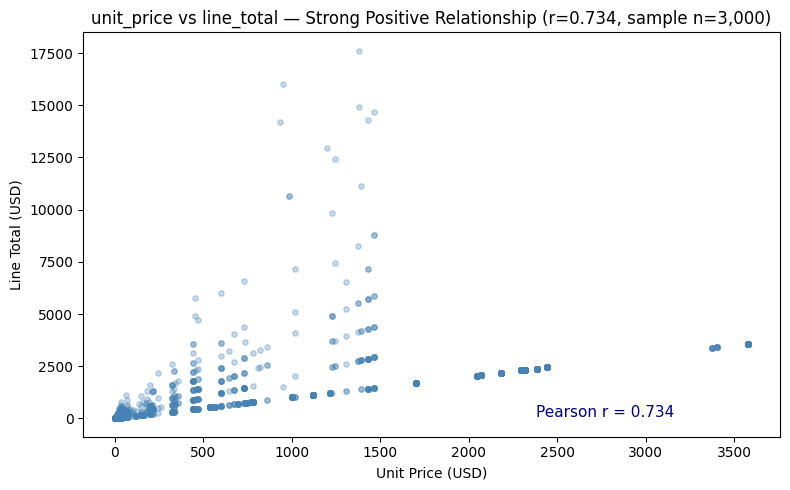

In [23]:
# Scatter plot using matplotlib — no row limits
df_scatter = df.sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    df_scatter['unit_price'],
    df_scatter['line_total'],
    alpha=0.3, s=15, color='steelblue'
)
ax.set_title('unit_price vs line_total — Strong Positive Relationship (r=0.734, sample n=3,000)', fontsize=12)
ax.set_xlabel('Unit Price (USD)')
ax.set_ylabel('Line Total (USD)')
ax.annotate('Pearson r = 0.734', xy=(0.65, 0.05),
            xycoords='axes fraction', fontsize=11, color='navy')
plt.tight_layout()
plt.show()

In [24]:
feature_2_insights = """
Feature: unit_price

unit_price is the price per unit for a given product on a given order line.
It is the strongest individual predictor of line_total (Pearson r = 0.734).

Statistics:
  Min: $1.33 | Median: $34.99 | Mean: $526.22 | Max: $3,578.27
  Standard deviation: $884.39 — very wide spread reflecting diverse product range.
  221 unique price points across 254 products.

Distribution:
  - Right-skewed: most products are low-cost accessories ($1.33–$35).
  - A smaller segment of high-value products (bikes) range up to $3,578.27.
  - The top 5 most common prices ($4.99, $34.99, $8.99, $2.29, $3.99) are all
    low-cost accessory items, reflecting high sales volume for cheap products.

Relationship with line_total:
  - Strong positive linear relationship (r = 0.734).
  - Higher unit price directly increases line_total, even at quantity = 1.
  - The scatter plot shows a clear upward trend with some spread caused by
    varying order quantities.

Modelling implication:
  - unit_price will be the most important feature in the regression model.
  - May also benefit from log transformation given its skewed distribution.
  - Should NOT be dropped despite being part of the line_total formula —
    it provides essential predictive signal.
"""

In [25]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### B.4 Explore Feature of Interest `\<order_quantity and unit_price_discount\>`

In [26]:
# order_quantity distribution
print("order_quantity — Descriptive Statistics:")
print(df['order_quantity'].describe().round(2))
print()
print(f"Skewness: {df['order_quantity'].skew():.3f}  ← right-skewed, most orders = 1 unit")
print()
print("Frequency of each quantity level (top 10):")
print(df['order_quantity'].value_counts().sort_index().head(10))
print()
pct_qty1 = (df['order_quantity'] == 1).mean() * 100
print(f"Orders with quantity = 1: {pct_qty1:.1f}% of all line items")

order_quantity — Descriptive Statistics:
count    42100.00
mean         1.70
std          2.02
min          1.00
25%          1.00
50%          1.00
75%          1.00
max         36.00
Name: order_quantity, dtype: float64

Skewness: 4.587  ← right-skewed, most orders = 1 unit

Frequency of each quantity level (top 10):
order_quantity
1.0     33901
2.0      2352
3.0      1676
4.0      1300
5.0       788
6.0       579
7.0       353
8.0       330
9.0       168
10.0      164
Name: count, dtype: int64

Orders with quantity = 1: 80.5% of all line items


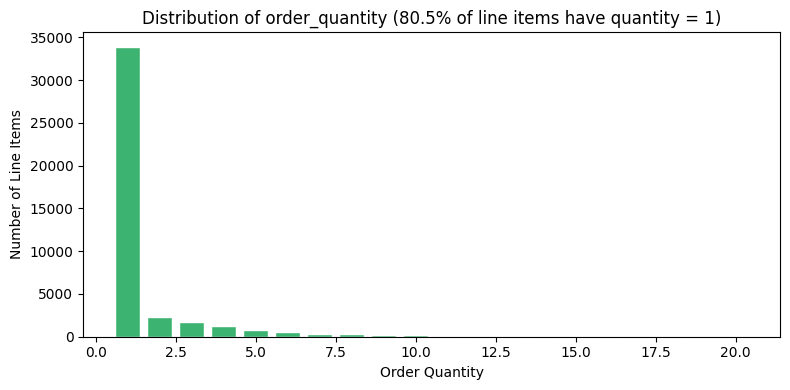

In [27]:
# Use pre-aggregated data — no row limit issue
qty_counts = df['order_quantity'].value_counts().sort_index().reset_index()
qty_counts.columns = ['order_quantity', 'count']

# Only keep quantities 1-20 for readability
qty_counts = qty_counts[qty_counts['order_quantity'] <= 20]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(qty_counts['order_quantity'], qty_counts['count'],
       color='mediumseagreen', edgecolor='white')
ax.set_title('Distribution of order_quantity (80.5% of line items have quantity = 1)', fontsize=12)
ax.set_xlabel('Order Quantity')
ax.set_ylabel('Number of Line Items')
plt.tight_layout()
plt.show()

In [28]:
# Detailed breakdown: how many orders at each discount level and their avg value
disc_summary = df.groupby('unit_price_discount').agg(
    count=('line_total', 'count'),
    avg_line_total=('line_total', 'mean'),
    avg_quantity=('order_quantity', 'mean')
).round(2)

disc_summary['% of orders'] = (disc_summary['count'] / len(df) * 100).round(2)
print("unit_price_discount breakdown:")
print(disc_summary)
print()
print("Key insight: 97.99% of all line items have NO discount (0.0)")
print("Discounts of 0.20 and 0.02 are linked to the highest average order values.")

unit_price_discount breakdown:
                     count  avg_line_total  avg_quantity  % of orders
unit_price_discount                                                  
0.00                 41253          705.94          1.54        97.99
0.02                   309         2095.82         12.16         0.73
0.05                   148         1738.20         17.50         0.35
0.10                    20          451.75         14.45         0.05
0.15                   233          839.01          3.86         0.55
0.20                    98         2537.82          3.33         0.23
0.30                     6         1260.61          7.67         0.01
0.40                    33          152.03          2.24         0.08

Key insight: 97.99% of all line items have NO discount (0.0)
Discounts of 0.20 and 0.02 are linked to the highest average order values.


In [29]:
# Detailed breakdown by discount level
disc_summary = df.groupby('unit_price_discount').agg(
    count=('line_total', 'count'),
    avg_line_total=('line_total', 'mean'),
    avg_quantity=('order_quantity', 'mean')
).round(2).reset_index()

disc_summary['pct_of_orders'] = (disc_summary['count'] / len(df) * 100).round(2)
print("unit_price_discount — Full Breakdown:")
print(disc_summary.to_string(index=False))
print()
print(f"Orders with NO discount (0.0): {41253/42100*100:.1f}% of all line items")
print("Orders with discount: only 847 rows — discounts are rare events")

unit_price_discount — Full Breakdown:
 unit_price_discount  count  avg_line_total  avg_quantity  pct_of_orders
                0.00  41253          705.94          1.54          97.99
                0.02    309         2095.82         12.16           0.73
                0.05    148         1738.20         17.50           0.35
                0.10     20          451.75         14.45           0.05
                0.15    233          839.01          3.86           0.55
                0.20     98         2537.82          3.33           0.23
                0.30      6         1260.61          7.67           0.01
                0.40     33          152.03          2.24           0.08

Orders with NO discount (0.0): 98.0% of all line items
Orders with discount: only 847 rows — discounts are rare events


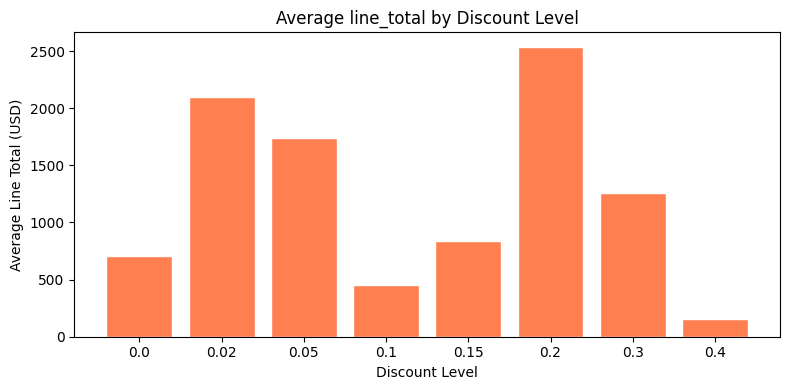

In [30]:
# Average line_total by discount level
disc_avg = df.groupby('unit_price_discount')['line_total'].mean().reset_index()
disc_avg.columns = ['discount', 'avg_line_total']
disc_avg['discount'] = disc_avg['discount'].astype(str)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(disc_avg['discount'], disc_avg['avg_line_total'],
       color='coral', edgecolor='white')
ax.set_title('Average line_total by Discount Level', fontsize=12)
ax.set_xlabel('Discount Level')
ax.set_ylabel('Average Line Total (USD)')
plt.tight_layout()
plt.show()

In [31]:
# <Student to fill this section>
feature_n_insights = """
Features: order_quantity and unit_price_discount

--- order_quantity ---
Range: 1 to 36. Mean: 1.70. Median: 1.0. Skewness: 4.587.

Distribution:
  - 80.5% of all line items have order_quantity = 1 (33,901 out of 42,100 rows).
  - Quantities above 10 units are very rare (less than 1% of all rows combined).
  - Strongly right-skewed — most customers buy a single unit per line item.

Relationship with line_total:
  - Moderate positive correlation with line_total (r = 0.248).
  - Average line_total rises steadily with quantity:
      qty=1: $565 | qty=3: $1,289 | qty=5: $1,637 | qty=10: $2,628
  - Relationship is noisier than unit_price because high-quantity orders can
    involve cheap accessories, keeping the total relatively low.

Modelling implication:
  - Keep as numeric feature. Consider log transform if linear models underperform.

--- unit_price_discount ---
Takes 8 discrete values: 0.0, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40.

Distribution:
  - 97.99% of line items have NO discount (41,253 of 42,100 rows).
  - Only 847 rows across all non-zero discount levels.
  - Discounts are applied through special promotional offers, not routinely.

Relationship with line_total:
  - Weak direct linear correlation (r = 0.045), but a clear non-linear pattern:
      0% discount:  avg $706  | 20% discount: avg $2,538
      40% discount: avg $152  | 2% discount:  avg $2,096
  - Higher discounts do NOT consistently lower line_total — instead, larger
    discounts tend to be applied to bulk or high-value premium orders.
  - A binary has_discount feature (1 if discount > 0, else 0) will be
    engineered in the preparation notebook to capture this signal cleanly.

Modelling implication:
  - Keep original unit_price_discount as numeric feature.
  - Add has_discount binary flag as an engineered feature.
  - The severe class imbalance (98% no discount) means the model will mostly
    learn from undiscounted orders — worth monitoring in residual analysis.
"""

In [32]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

In [33]:
# Load product table to understand what product_id represents
product_df = pd.read_csv(at.folder_path / "product.csv")
product_sub_df = pd.read_csv(at.folder_path / "product_sub_category.csv")
product_cat_df = pd.read_csv(at.folder_path / "product_category.csv")

print("Product table shape:", product_df.shape)
print("Columns:", product_df.columns.tolist())
print()
print("Unique products in sales_order_detail:", df['product_id'].nunique())
print("Top 5 most ordered product_ids:")
print(df['product_id'].value_counts().head(5))
print()

# Average line_total per product (top 10 by revenue)
avg_by_product = df.groupby('product_id')['line_total'].mean().sort_values(ascending=False)
print("Top 5 highest avg line_total by product:")
print(avg_by_product.head(5).round(2))

Product table shape: (886, 23)
Columns: ['product_id', 'is_manufactured', 'is_sellable', 'safety_stock_level', 'reorder_point', 'days_to_manufacture', 'product_subcategory_id', 'product_model_id', 'name', 'product_number', 'color', 'standard_cost', 'list_price', 'size', 'size_unit_measure_code', 'weight_unit_measure_code', 'weight', 'product_line', 'class', 'style', 'sell_start_date', 'sell_end_date', 'discontinued_date']

Unique products in sales_order_detail: 254
Top 5 most ordered product_ids:
product_id
4782606a-0c9b-477e-9e0f-e996d5c298e2    2156
eca4e568-b2dc-4f1e-aa55-444911bfedcf    1572
36847649-a79a-4f70-9b5d-5c403627ab75    1457
c0429100-f92a-42a4-afa5-b652cee57249    1407
05385566-38df-4855-94a8-786cae6ffe49    1373
Name: count, dtype: int64

Top 5 highest avg line_total by product:
product_id
b443720f-61f8-4c60-aff8-a1a2acccec4e    3676.92
e8c12ae4-8042-4b77-8bd7-023d46440e33    3578.27
41b7b226-20ea-488a-b519-b4ca65d4a64e    3578.27
e909a64f-f56c-4f3c-b802-f539d52f8f21   

In [34]:
# Load product table to understand what product_id represents
product_df = pd.read_csv(at.folder_path / "product.csv")
product_sub_df = pd.read_csv(at.folder_path / "product_sub_category.csv")
product_cat_df = pd.read_csv(at.folder_path / "product_category.csv")

print("Product table shape:", product_df.shape)
print("Columns:", product_df.columns.tolist())
print()
print("Unique products in sales_order_detail:", df['product_id'].nunique())
print("Top 5 most ordered product_ids:")
print(df['product_id'].value_counts().head(5))
print()

# Average line_total per product (top 10 by revenue)
avg_by_product = df.groupby('product_id')['line_total'].mean().sort_values(ascending=False)
print("Top 5 highest avg line_total by product:")
print(avg_by_product.head(5).round(2))

Product table shape: (886, 23)
Columns: ['product_id', 'is_manufactured', 'is_sellable', 'safety_stock_level', 'reorder_point', 'days_to_manufacture', 'product_subcategory_id', 'product_model_id', 'name', 'product_number', 'color', 'standard_cost', 'list_price', 'size', 'size_unit_measure_code', 'weight_unit_measure_code', 'weight', 'product_line', 'class', 'style', 'sell_start_date', 'sell_end_date', 'discontinued_date']

Unique products in sales_order_detail: 254
Top 5 most ordered product_ids:
product_id
4782606a-0c9b-477e-9e0f-e996d5c298e2    2156
eca4e568-b2dc-4f1e-aa55-444911bfedcf    1572
36847649-a79a-4f70-9b5d-5c403627ab75    1457
c0429100-f92a-42a4-afa5-b652cee57249    1407
05385566-38df-4855-94a8-786cae6ffe49    1373
Name: count, dtype: int64

Top 5 highest avg line_total by product:
product_id
b443720f-61f8-4c60-aff8-a1a2acccec4e    3676.92
e8c12ae4-8042-4b77-8bd7-023d46440e33    3578.27
41b7b226-20ea-488a-b519-b4ca65d4a64e    3578.27
e909a64f-f56c-4f3c-b802-f539d52f8f21   

In [35]:
# Load sales_order_header for order-level features (date, territory)
soh_df = pd.read_csv(at.folder_path / "sales_order_header.csv")

print("Sales order header shape:", soh_df.shape)
print("Columns:", soh_df.columns.tolist())
print()

# Lines per order
lines_per_order = df.groupby('sales_order_id').size()
print("Lines per order stats:")
print(lines_per_order.describe().round(2))
print()
print("Most orders have 1-3 line items — joining header gives us date and territory features")

Sales order header shape: (31465, 17)
Columns: ['sales_order_id', 'revision_number', 'status', 'online_order_flag', 'customer_id', 'sales_person_id', 'territory_id', 'currency_rate_id', 'order_date', 'due_date', 'ship_date', 'sales_order_number', 'account_number', 'sub_total', 'tax_amount', 'freight', 'total_due']

Lines per order stats:
count    15357.00
mean         2.74
std          4.74
min          1.00
25%          1.00
50%          2.00
75%          3.00
max         72.00
dtype: float64

Most orders have 1-3 line items — joining header gives us date and territory features
